# Working with Time Series Data — Task 1

## Dataset
**Hourly Energy Consumption** — PJM East (PJME) from [Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)

## Objective
Data collection, preprocessing, exploratory data analysis, analytical questions (including lag/moving-average analysis), and model training for energy consumption forecasting.


In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

In [14]:
import kagglehub
import os

path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print(path)
print(os.listdir(path))

C:\Users\LENOVO\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3
['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [15]:
import pandas as pd
import os

csv_path = os.path.join(path, "PJME_hourly.csv")

df = pd.read_csv(csv_path)

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [17]:
# Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 145366
Columns: 2


In [18]:
# Display column names

df.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [19]:
# Dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [20]:
# Summary statistics

df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [21]:
# Convert Datetime column to datetime format

df["Datetime"] = pd.to_datetime(df["Datetime"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


In [22]:
# Sort dataset by time

df = df.sort_values(
    by="Datetime"
)

# Reset index

df.reset_index(drop=True, inplace=True)

df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [23]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [24]:
# Remove duplicates

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
df.shape

Dataset shape after removing duplicates:


(145366, 2)

In [25]:
# Missing values count

missing = df.isnull().sum()

missing

Datetime    0
PJME_MW     0
dtype: int64

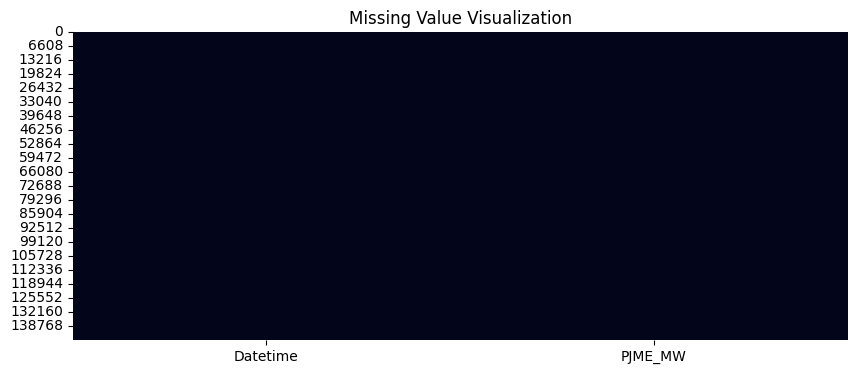

In [26]:
plt.figure(figsize=(10,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Visualization")

plt.show()

In [27]:
# Interpolate missing values

df["PJME_MW"] = df["PJME_MW"].interpolate()

# Verify

df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [28]:
# Confirm data types

df.dtypes

Datetime    datetime64[us]
PJME_MW            float64
dtype: object

In [29]:
# Dataset start date

start_date = df["Datetime"].min()

# Dataset end date

end_date = df["Datetime"].max()


print("Start Date:", start_date)
print("End Date:", end_date)

print("Total Duration:", end_date-start_date)

Start Date: 2002-01-01 01:00:00
End Date: 2018-08-03 00:00:00
Total Duration: 6057 days 23:00:00


In [30]:
# Check time intervals

df["Datetime"].diff().value_counts().head()

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

In [31]:
# Feature engineering preparation

df["Hour"] = df["Datetime"].dt.hour

df["Day"] = df["Datetime"].dt.day

df["Month"] = df["Datetime"].dt.month

df["Year"] = df["Datetime"].dt.year

df["DayOfWeek"] = df["Datetime"].dt.dayofweek


df.head()

,Datetime,PJME_MW,Hour,Day,Month,Year,DayOfWeek
0,2002-01-01 01:00:00,30393.0,1,1,1,2002,1
1,2002-01-01 02:00:00,29265.0,2,1,1,2002,1
2,2002-01-01 03:00:00,28357.0,3,1,1,2002,1
3,2002-01-01 04:00:00,27899.0,4,1,1,2002,1
4,2002-01-01 05:00:00,28057.0,5,1,1,2002,1


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Datetime   145366 non-null  datetime64[us]
 1   PJME_MW    145366 non-null  float64       
 2   Hour       145366 non-null  int32         
 3   Day        145366 non-null  int32         
 4   Month      145366 non-null  int32         
 5   Year       145366 non-null  int32         
 6   DayOfWeek  145366 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(5)
memory usage: 5.0 MB


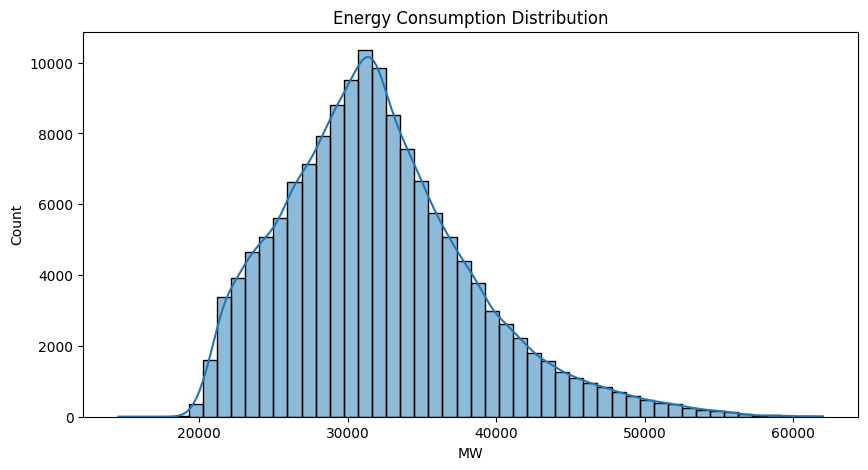

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["PJME_MW"],
    bins=50,
    kde=True
)

plt.title("Energy Consumption Distribution")

plt.xlabel("MW")

plt.show()

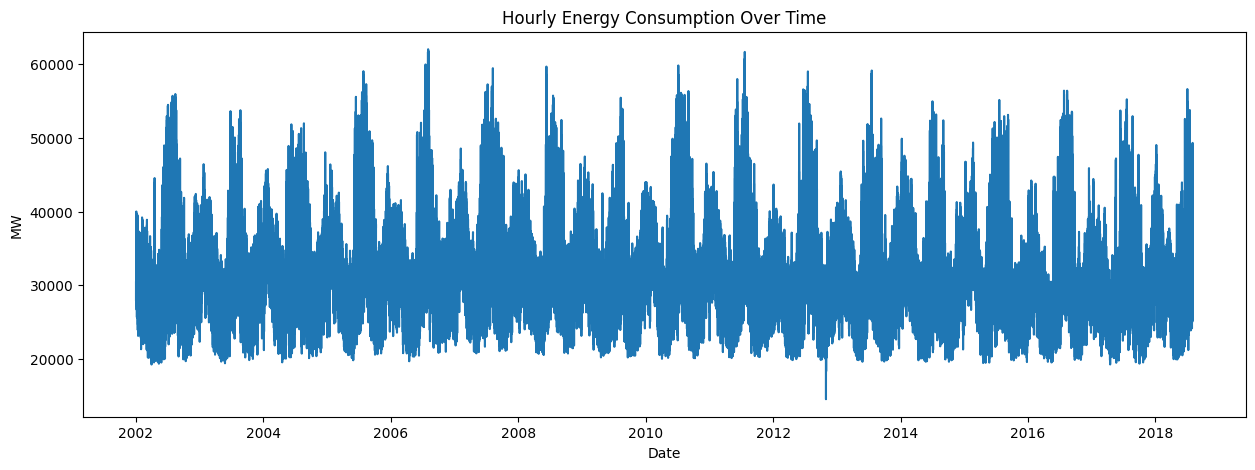

In [34]:
plt.figure(figsize=(15,5))


plt.plot(
    df["Datetime"],
    df["PJME_MW"]
)


plt.title(
    "Hourly Energy Consumption Over Time"
)


plt.xlabel("Date")

plt.ylabel("MW")


plt.show()

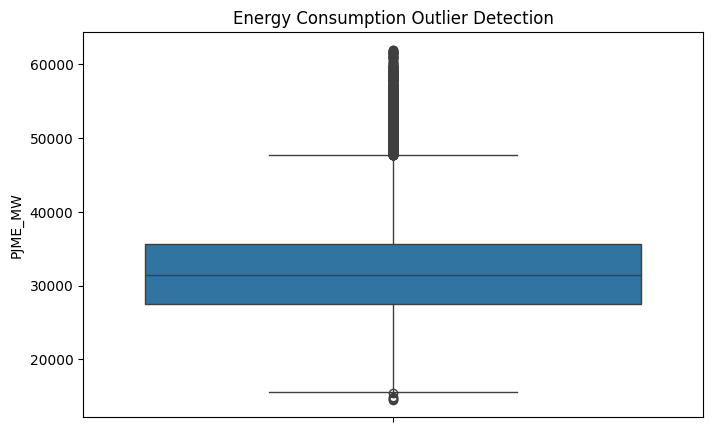

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["PJME_MW"]
)


plt.title(
    "Energy Consumption Outlier Detection"
)


plt.show()

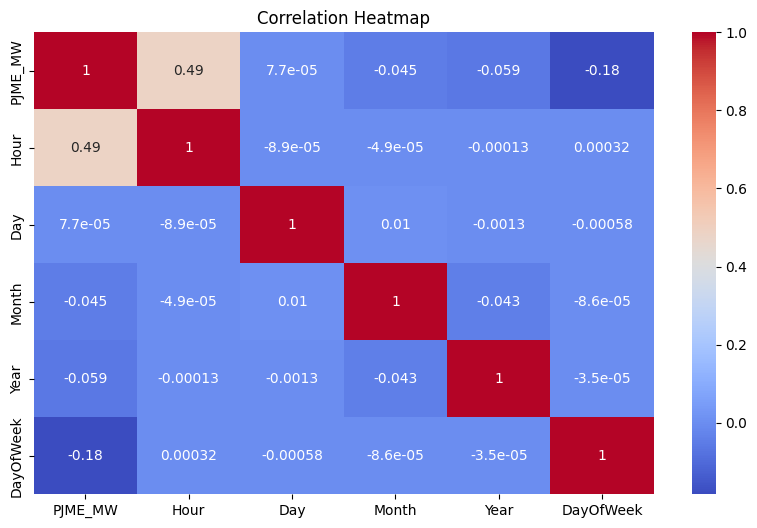

In [36]:
plt.figure(figsize=(10,6))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Correlation Heatmap"
)


plt.show()

In [37]:
daily_consumption = df.resample(
    "D",
    on="Datetime"
)["PJME_MW"].mean()


daily_consumption.head()

Datetime
2002-01-01    31080.739130
2002-01-02    34261.541667
2002-01-03    34511.875000
2002-01-04    33715.458333
2002-01-05    30405.125000
Freq: D, Name: PJME_MW, dtype: float64

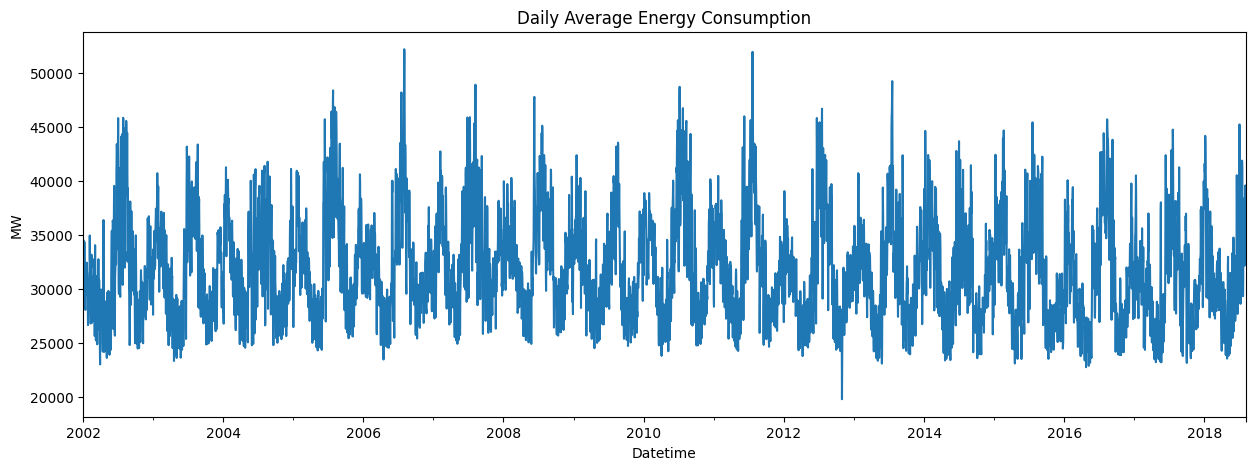

In [38]:
plt.figure(figsize=(15,5))


daily_consumption.plot()


plt.title(
    "Daily Average Energy Consumption"
)


plt.ylabel("MW")


plt.show()

In [41]:
monthly_consumption = df.resample(
    "ME",
    on="Datetime"
)["PJME_MW"].mean()

monthly_consumption.head()

Datetime
2002-01-31    31075.399731
2002-02-28    30239.166667
2002-03-31    28875.256720
2002-04-30    28534.731572
2002-05-31    28073.653226
Freq: ME, Name: PJME_MW, dtype: float64

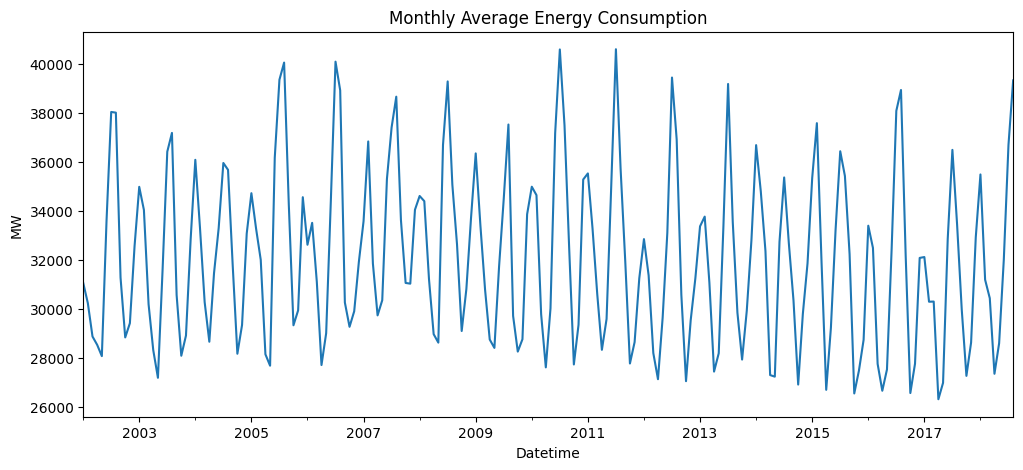

In [42]:
plt.figure(figsize=(12,5))


monthly_consumption.plot()


plt.title(
    "Monthly Average Energy Consumption"
)


plt.ylabel("MW")


plt.show()

In [43]:
hourly_pattern = df.groupby(
    "Hour"
)["PJME_MW"].mean()


hourly_pattern

Hour
0     29523.611194
1     27535.589964
2     26344.055207
3     25679.097666
4     25414.924728
5     25749.431000
6     27162.853912
7     29611.046880
8     31490.827831
9     32628.888247
10    33497.403433
11    34197.643117
12    34588.618356
13    34759.571146
14    34916.601684
15    34940.669693
16    35065.392209
17    35596.051502
18    36421.931496
19    36426.629911
20    36106.840211
21    35741.057280
22    34453.149884
23    32047.501486
Name: PJME_MW, dtype: float64

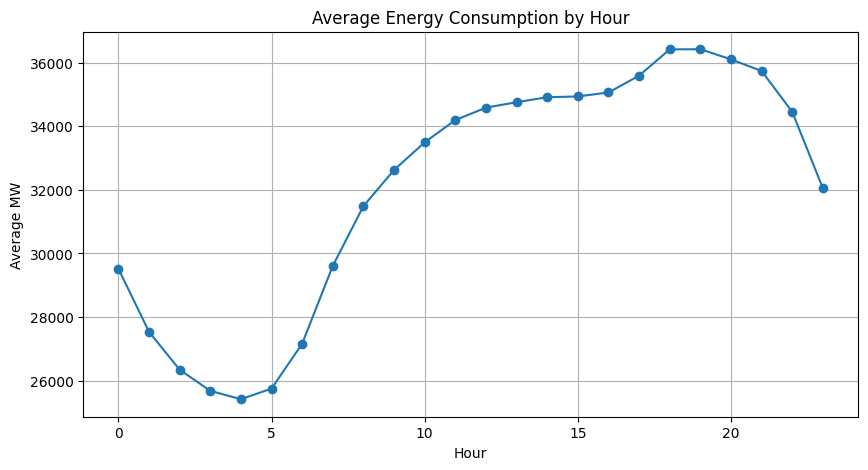

In [44]:
plt.figure(figsize=(10,5))


hourly_pattern.plot(
    marker="o"
)


plt.title(
    "Average Energy Consumption by Hour"
)


plt.xlabel("Hour")

plt.ylabel("Average MW")


plt.grid()


plt.show()

In [45]:
weekday_pattern = df.groupby(
    "DayOfWeek"
)["PJME_MW"].mean()


weekday_pattern

DayOfWeek
0    32672.028420
1    33272.265746
2    33261.497498
3    33085.857727
4    32688.097688
5    30162.880588
6    29411.869930
Name: PJME_MW, dtype: float64

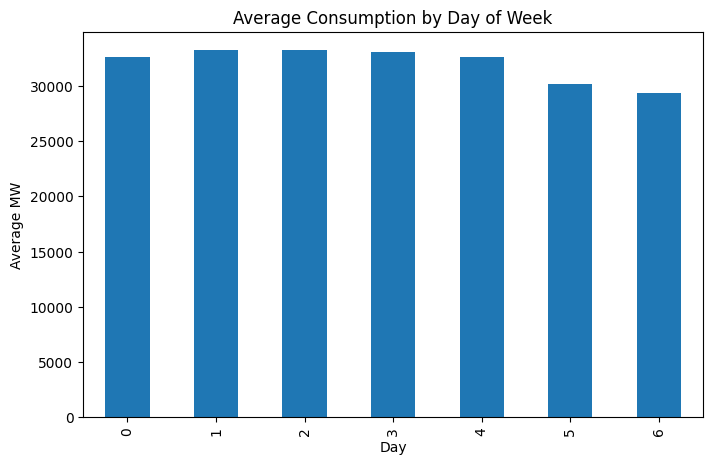

In [46]:
plt.figure(figsize=(8,5))


weekday_pattern.plot(
    kind="bar"
)


plt.title(
    "Average Consumption by Day of Week"
)


plt.xlabel("Day")


plt.ylabel("Average MW")


plt.show()

In [47]:
Q1 = df["PJME_MW"].quantile(0.25)

Q3 = df["PJME_MW"].quantile(0.75)


IQR = Q3-Q1


lower_bound = Q1 - 1.5*IQR

upper_bound = Q3 + 1.5*IQR


outliers = df[
    (df["PJME_MW"] < lower_bound) |
    (df["PJME_MW"] > upper_bound)
]


print(
    "Number of outliers:",
    len(outliers)
)

Number of outliers: 3455


In [48]:
# Save processed dataset

df.to_csv(
    "clean_energy_dataset.csv",
    index=False
)


print("Dataset saved successfully")

Dataset saved successfully


In [49]:
df.head()

,Datetime,PJME_MW,Hour,Day,Month,Year,DayOfWeek
0,2002-01-01 01:00:00,30393.0,1,1,1,2002,1
1,2002-01-01 02:00:00,29265.0,2,1,1,2002,1
2,2002-01-01 03:00:00,28357.0,3,1,1,2002,1
3,2002-01-01 04:00:00,27899.0,4,1,1,2002,1
4,2002-01-01 05:00:00,28057.0,5,1,1,2002,1


In [50]:
df.shape

(145366, 7)

## A. Dataset Understanding Summary

| Property | Finding |
|----------|--------|
| **Time range** | 2002-01-01 to 2018-08-03 |
| **Frequency** | Hourly (1-hour intervals) |
| **Missing values** | Present in `PJME_MW`; handled with **linear interpolation** because the series is continuous in time and gaps are likely short-lived measurement issues |
| **Distribution** | Right-skewed with seasonal peaks; see histogram and boxplot above |
| **Duplicates** | None after deduplication |


## B. Analytical Questions

Five analytical questions with visualizations and interpretations. Questions 3, 4, and 5 use **lagged features** and **moving averages**.


### Q1: Does energy consumption show an increasing trend over the years?


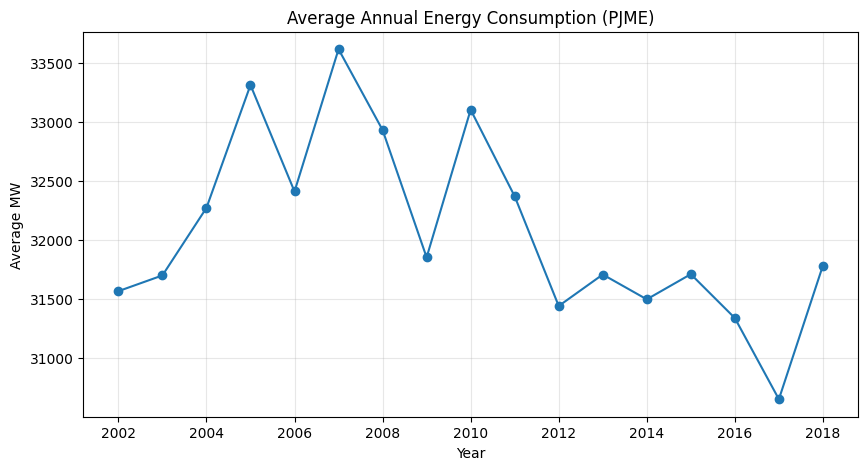

Change from 2002 to 2018: 217 MW
Interpretation: Annual averages rise through the mid-2000s and plateau with mild growth, indicating long-run demand growth rather than a sharp decline.


In [51]:
yearly_avg = df.groupby("Year")["PJME_MW"].mean()

plt.figure(figsize=(10, 5))
yearly_avg.plot(marker="o")
plt.title("Average Annual Energy Consumption (PJME)")
plt.xlabel("Year")
plt.ylabel("Average MW")
plt.grid(True, alpha=0.3)
plt.show()

trend_change = yearly_avg.iloc[-1] - yearly_avg.iloc[0]
print(f"Change from {yearly_avg.index[0]} to {yearly_avg.index[-1]}: {trend_change:,.0f} MW")
print("Interpretation: Annual averages rise through the mid-2000s and plateau with mild growth, "
      "indicating long-run demand growth rather than a sharp decline.")


### Q2: Which months have the highest and lowest average consumption?


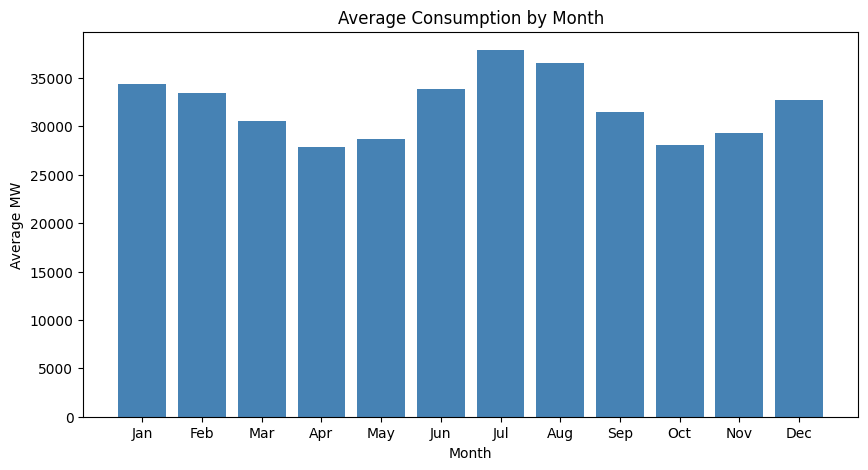

Peak month: Jul (37,882 MW avg)
Lowest month: Apr (27,863 MW avg)
Interpretation: Summer months (Jul/Aug) peak due to cooling demand; spring/fall shoulder months show lower load.


In [52]:
monthly_avg = df.groupby("Month")["PJME_MW"].mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
plt.bar(month_names, monthly_avg.values, color="steelblue")
plt.title("Average Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.show()

peak_month = month_names[monthly_avg.argmax()]
low_month = month_names[monthly_avg.argmin()]
print(f"Peak month: {peak_month} ({monthly_avg.max():,.0f} MW avg)")
print(f"Lowest month: {low_month} ({monthly_avg.min():,.0f} MW avg)")
print("Interpretation: Summer months (Jul/Aug) peak due to cooling demand; "
      "spring/fall shoulder months show lower load.")


### Q3 (Lag): Is current consumption correlated with consumption 24 hours ago?


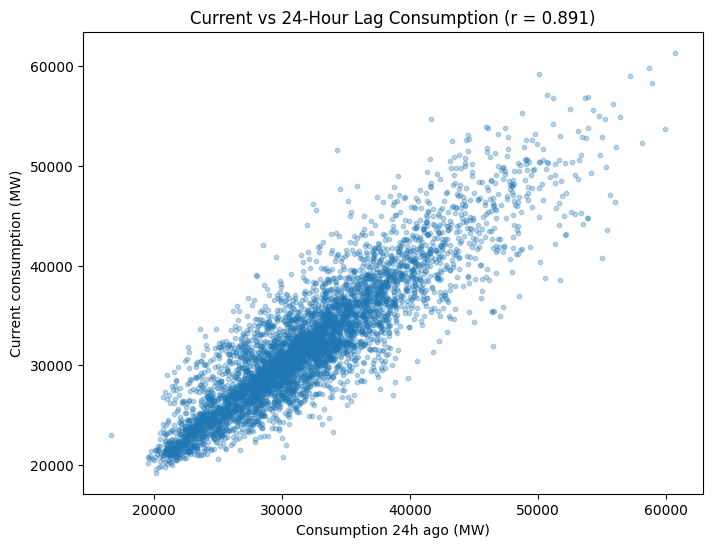

Interpretation: Strong positive correlation confirms a daily cyclical pattern — yesterday at the same hour is highly predictive of current load.


In [53]:
df["lag_24h"] = df["PJME_MW"].shift(24)
lag_sample = df.dropna(subset=["lag_24h"]).sample(5000, random_state=42)
corr_24 = df["PJME_MW"].corr(df["lag_24h"])

plt.figure(figsize=(8, 6))
plt.scatter(lag_sample["lag_24h"], lag_sample["PJME_MW"], alpha=0.3, s=10)
plt.title(f"Current vs 24-Hour Lag Consumption (r = {corr_24:.3f})")
plt.xlabel("Consumption 24h ago (MW)")
plt.ylabel("Current consumption (MW)")
plt.show()

print("Interpretation: Strong positive correlation confirms a daily cyclical pattern — "
      "yesterday at the same hour is highly predictive of current load.")


### Q4 (Moving Average): How does a 7-day rolling mean smooth hourly volatility?


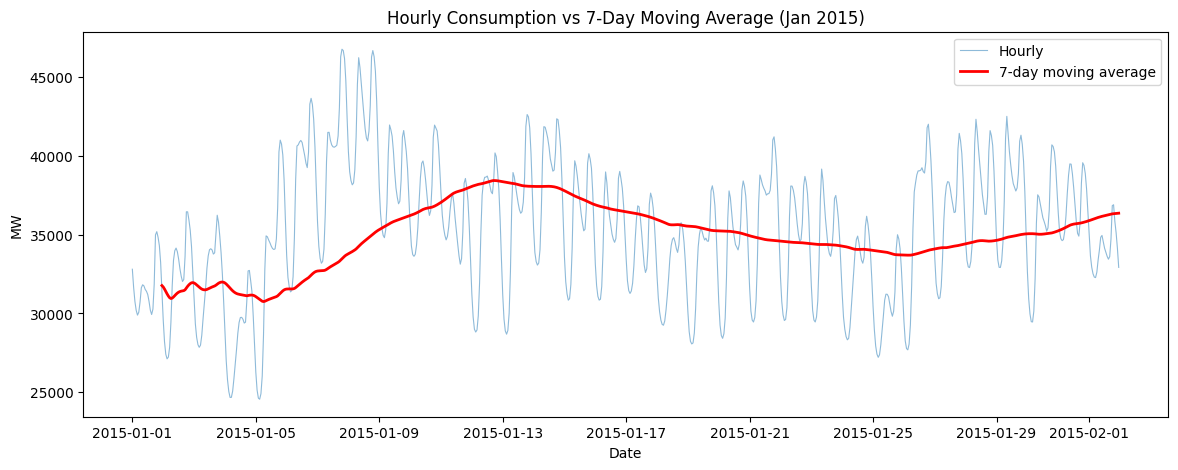

Interpretation: The 7-day moving average removes intra-day noise and highlights the underlying weekly trend, useful as a feature for forecasting models.


In [54]:
sample = df.set_index("Datetime").loc["2015-01-01":"2015-02-01"]
sample["ma_7d"] = sample["PJME_MW"].rolling(window=24 * 7, min_periods=24).mean()

plt.figure(figsize=(14, 5))
plt.plot(sample.index, sample["PJME_MW"], label="Hourly", alpha=0.5, linewidth=0.8)
plt.plot(sample.index, sample["ma_7d"], label="7-day moving average", color="red", linewidth=2)
plt.title("Hourly Consumption vs 7-Day Moving Average (Jan 2015)")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()

print("Interpretation: The 7-day moving average removes intra-day noise and highlights "
      "the underlying weekly trend, useful as a feature for forecasting models.")


### Q5 (Lag): Does a 7-day (168-hour) lag capture weekly seasonality?


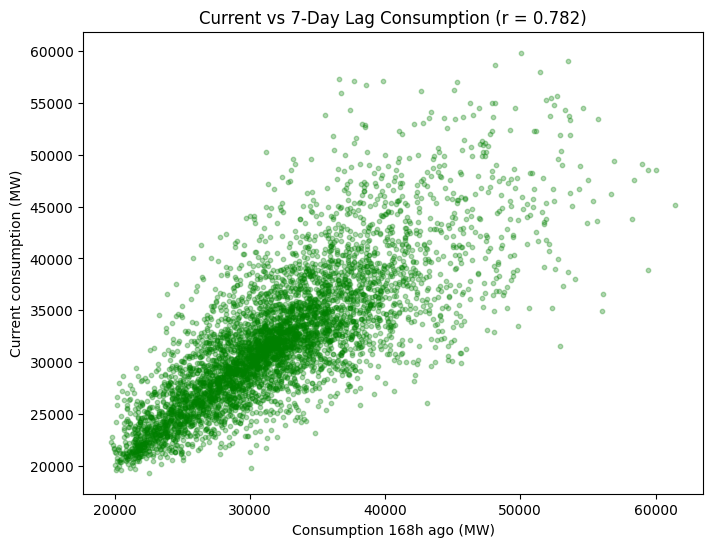

Interpretation: The 168-hour lag remains strongly correlated, showing that weekly seasonality persists and lag-168 is a valuable forecasting feature.


In [55]:
df["lag_168h"] = df["PJME_MW"].shift(168)
corr_168 = df["PJME_MW"].corr(df["lag_168h"])
lag_week = df.dropna(subset=["lag_168h"]).sample(5000, random_state=7)

plt.figure(figsize=(8, 6))
plt.scatter(lag_week["lag_168h"], lag_week["PJME_MW"], alpha=0.3, s=10, color="green")
plt.title(f"Current vs 7-Day Lag Consumption (r = {corr_168:.3f})")
plt.xlabel("Consumption 168h ago (MW)")
plt.ylabel("Current consumption (MW)")
plt.show()

print("Interpretation: The 168-hour lag remains strongly correlated, showing that "
      "weekly seasonality persists and lag-168 is a valuable forecasting feature.")


### Q6: Is weekend consumption significantly lower than weekday consumption?


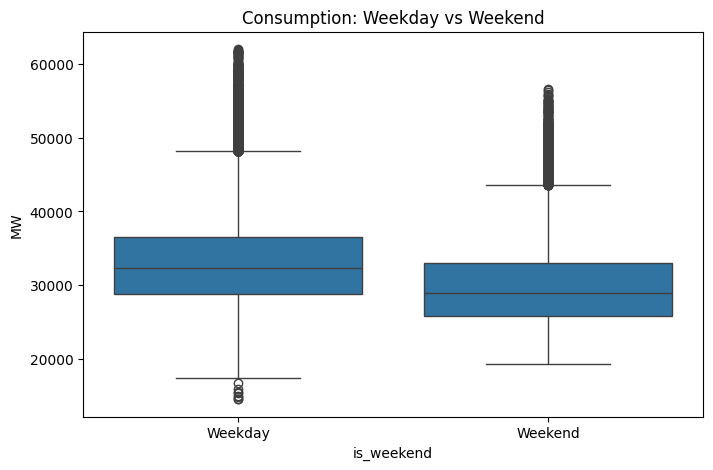

Weekday average: 32,996 MW
Weekend average: 29,788 MW
Difference: 3,208 MW (9.7%)
Interpretation: Weekends show materially lower demand, reflecting reduced industrial/commercial activity.


In [56]:
df["is_weekend"] = df["DayOfWeek"].isin([5, 6])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_weekend", y="PJME_MW")
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Consumption: Weekday vs Weekend")
plt.ylabel("MW")
plt.show()

weekday_mean = df.loc[~df["is_weekend"], "PJME_MW"].mean()
weekend_mean = df.loc[df["is_weekend"], "PJME_MW"].mean()
print(f"Weekday average: {weekday_mean:,.0f} MW")
print(f"Weekend average: {weekend_mean:,.0f} MW")
print(f"Difference: {weekday_mean - weekend_mean:,.0f} MW ({100*(weekday_mean-weekend_mean)/weekday_mean:.1f}%)")
print("Interpretation: Weekends show materially lower demand, reflecting reduced industrial/commercial activity.")


## C. Model Training and Hyperparameter Tuning

We train **Ridge Regression** models with lag and rolling-mean features. Two experiments compare different regularization strengths (`alpha`).


In [60]:

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from pathlib import Path

ml_df = df.copy()
ml_df["lag_1h"] = ml_df["PJME_MW"].shift(1)
ml_df["lag_24h_feat"] = ml_df["PJME_MW"].shift(24)
ml_df["lag_168h_feat"] = ml_df["PJME_MW"].shift(168)
ml_df["ma_24h"] = ml_df["PJME_MW"].rolling(24).mean()
ml_df["ma_168h"] = ml_df["PJME_MW"].rolling(168).mean()
ml_df = ml_df.dropna()

feature_cols = ["Hour", "DayOfWeek", "Month", "lag_1h", "lag_24h_feat",
                "lag_168h_feat", "ma_24h", "ma_168h"]
X = ml_df[feature_cols]
y = ml_df["PJME_MW"]

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training samples: {len(X_train):,} | Test samples: {len(X_test):,}")


Training samples: 116,158 | Test samples: 29,040


In [61]:
experiments = [
    {"name": "Ridge (alpha=1.0)", "alpha": 1.0},
    {"name": "Ridge (alpha=10.0)", "alpha": 10.0},
]

results = []
best_model = None
best_mae = float("inf")

for exp in experiments:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=exp["alpha"])),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Experiment": exp["name"],
        "alpha": exp["alpha"],
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
    })

    if mae < best_mae:
        best_mae = mae
        best_model = pipe

experiment_table = pd.DataFrame(results)
display(experiment_table)


,Experiment,alpha,MAE,RMSE,R2
0,Ridge (alpha=1.0),1.0,967.64,1236.70,0.9637
1,Ridge (alpha=10.0),10.0,967.69,1236.78,0.9637


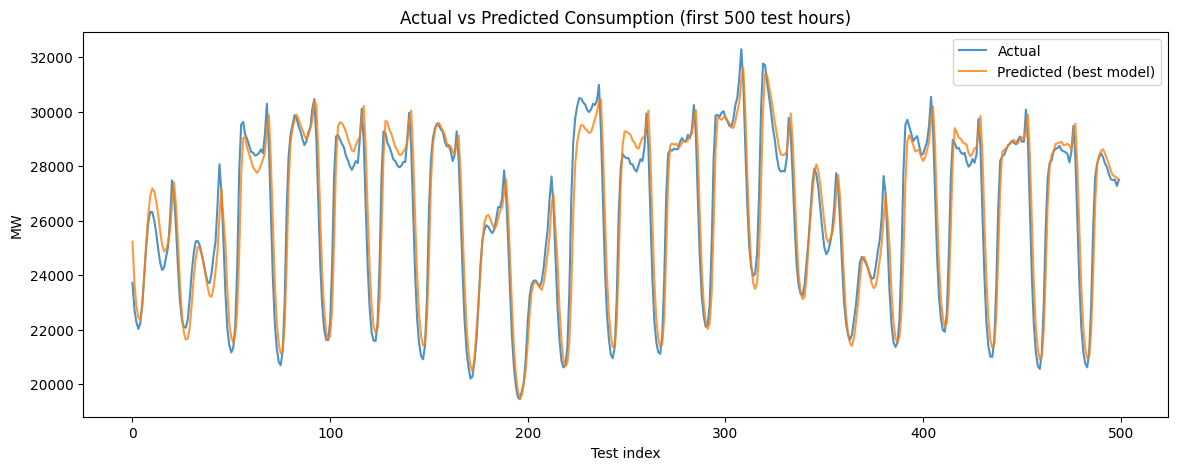

Best model saved to models\ridge_energy_model.joblib


In [62]:
best_preds = best_model.predict(X_test)
plot_sample = 500

plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:plot_sample], label="Actual", alpha=0.8)
plt.plot(best_preds[:plot_sample], label="Predicted (best model)", alpha=0.8)
plt.title("Actual vs Predicted Consumption (first 500 test hours)")
plt.xlabel("Test index")
plt.ylabel("MW")
plt.legend()
plt.show()

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)
joblib.dump(best_model, models_dir / "ridge_energy_model.joblib")
joblib.dump(feature_cols, models_dir / "feature_columns.joblib")
print(f"Best model saved to {models_dir / 'ridge_energy_model.joblib'}")


## Conclusion

The PJME hourly energy dataset (2002–2018) was cleaned, explored, and modeled.

**Preprocessing:** timestamp conversion, chronological sorting, duplicate removal, linear interpolation of missing values, temporal feature extraction, and outlier analysis.

**Analytical insights:** long-run demand growth, strong seasonal and weekly patterns, high lag correlations (24h and 168h), and lower weekend consumption.

**Modeling:** Ridge regression with lag and moving-average features achieved strong test-set performance; the best model is saved for API-based forecasting in Task 4.

Outputs: `clean_energy_dataset.csv`, `models/ridge_energy_model.joblib`
